In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

df = sns.load_dataset("mpg")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [20]:
df = df[['horsepower','mpg']]

In [22]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  392 non-null    float64
 1   mpg         398 non-null    float64
dtypes: float64(2)
memory usage: 6.3 KB


horsepower    6
mpg           0
dtype: int64

In [24]:
df = df.dropna()
df.shape

(392, 2)

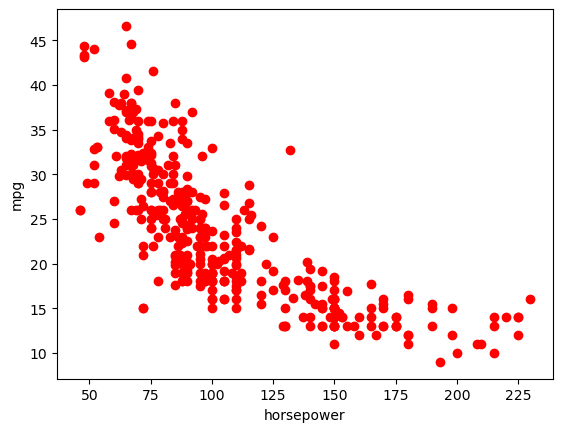

In [26]:
plt.scatter(df['horsepower'], df['mpg'], color = 'red')
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

In [27]:
X = df[['horsepower']]
y = df[['mpg']]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 15)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
regression = LinearRegression()
regression.fit(X_train, y_train)
y_pred = regression.predict(X_test)
print(r2_score(y_test, y_pred))

0.5570680987647478


In [32]:
poly = PolynomialFeatures(degree = 2, include_bias= True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
print(r2_score(y_test, y_pred))

0.6750814474139646


In [33]:
poly = PolynomialFeatures(degree = 3, include_bias= True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
print(r2_score(y_test, y_pred))

0.6729482613896041


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

X_new = pd.DataFrame(
    {"horsepower": np.linspace(df["horsepower"].min(),
    df["horsepower"].max(), 200)}
)

In [35]:
def poly_regression(degree):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree = degree)),
        ('lin_reg', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print('Degree:', degree , 'R2:', round(score,3))

    plt.plot(X_new, pipeline.predict(X_new), 'r', label = 'Tahmin')
    plt.scatter(X_train, y_train, label = 'Train')
    plt.scatter(X_test, y_test, label = 'Test')
    plt.xlabel('horsepower')
    plt.ylabel('mpg')
    plt.legend()
    plt.show()

Degree: 1 R2: 0.557


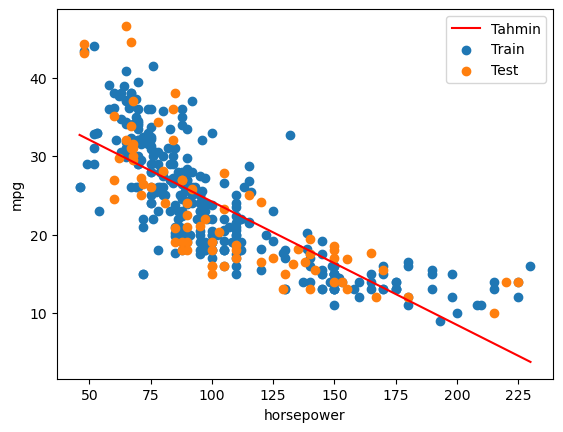

Degree: 2 R2: 0.675


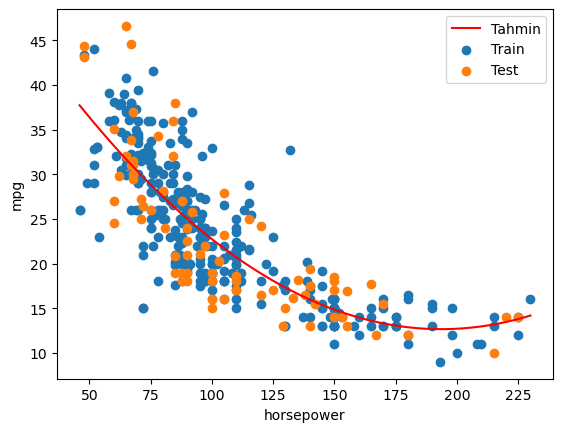

Degree: 3 R2: 0.673


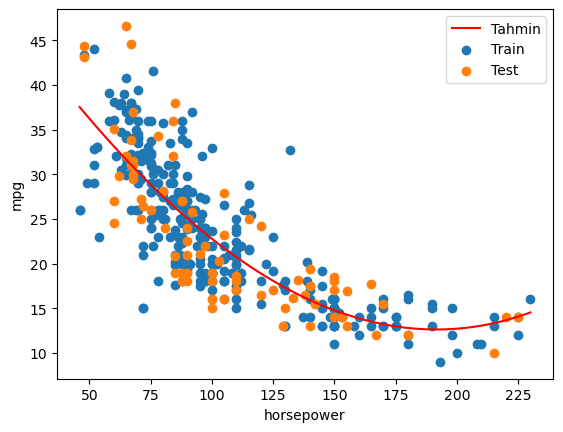

Degree: 4 R2: 0.668


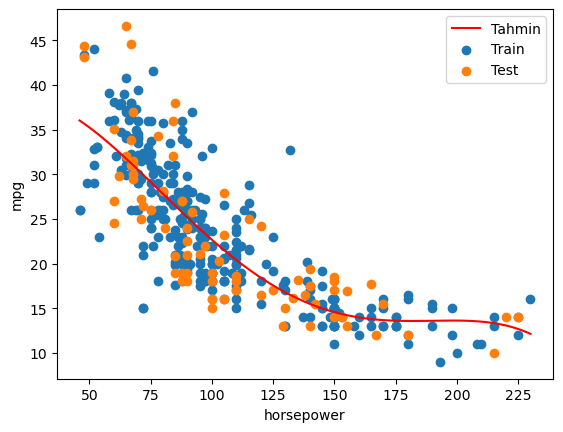

In [36]:
for d in [1,2,3,4]:
    poly_regression(d)